In [1]:
# =============================================================================
# PHASE 1: DATA LOADING & PREPROCESSING
# Intelligent Adaptive Credit Scoring Model
# German Credit Dataset — 1,000 instances, 21 columns
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

In [2]:

# =============================================================================
# STEP 1: LOAD DATA
# =============================================================================
df = pd.read_csv(r"C:\Users\lenovo\Desktop\Credit Scoring Model\Data\germancredit.csv")


In [3]:
print("=" * 60)
print("STEP 1: DATA LOADING")
print("=" * 60)
print(f"Shape          : {df.shape}")
print(f"Rows           : {df.shape[0]}")
print(f"Columns        : {df.shape[1]}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")

STEP 1: DATA LOADING
Shape          : (1000, 21)
Rows           : 1000
Columns        : 21
Missing Values : 0
Duplicates     : 0


In [4]:
 print(df.dtypes)          # Check data types

Default             int64
checkingstatus1    object
duration            int64
history            object
purpose            object
amount              int64
savings            object
employ             object
installment         int64
status             object
others             object
residence           int64
property           object
age                 int64
otherplans         object
housing            object
cards               int64
job                object
liable              int64
tele               object
foreign            object
dtype: object


In [5]:
print(df.isnull().sum())  # Confirm no missing values

Default            0
checkingstatus1    0
duration           0
history            0
purpose            0
amount             0
savings            0
employ             0
installment        0
status             0
others             0
residence          0
property           0
age                0
otherplans         0
housing            0
cards              0
job                0
liable             0
tele               0
foreign            0
dtype: int64


In [6]:
print(df.describe())

           Default     duration        amount  installment    residence  \
count  1000.000000  1000.000000   1000.000000  1000.000000  1000.000000   
mean      0.300000    20.903000   3271.258000     2.973000     2.845000   
std       0.458487    12.058814   2822.736876     1.118715     1.103718   
min       0.000000     4.000000    250.000000     1.000000     1.000000   
25%       0.000000    12.000000   1365.500000     2.000000     2.000000   
50%       0.000000    18.000000   2319.500000     3.000000     3.000000   
75%       1.000000    24.000000   3972.250000     4.000000     4.000000   
max       1.000000    72.000000  18424.000000     4.000000     4.000000   

               age        cards       liable  
count  1000.000000  1000.000000  1000.000000  
mean     35.546000     1.407000     1.155000  
std      11.375469     0.577654     0.362086  
min      19.000000     1.000000     1.000000  
25%      27.000000     1.000000     1.000000  
50%      33.000000     1.000000     1.0000


STEP 2: CLASS DISTRIBUTION
  Good Credit (0) : 700  (70.0%)
  Bad  Credit (1) : 300  (30.0%)
  Imbalance Ratio : 2.33:1

  [Saved] distributions.png


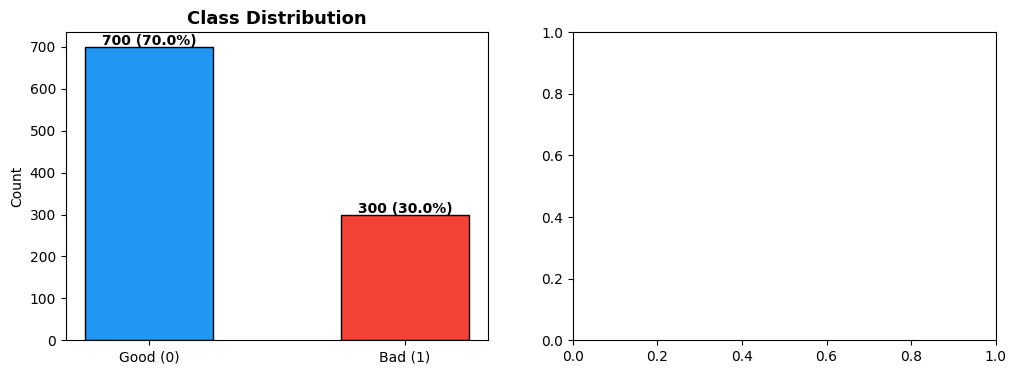

In [7]:
# =============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2: CLASS DISTRIBUTION")
print("=" * 60)

class_counts = df['Default'].value_counts()
class_pct    = df['Default'].value_counts(normalize=True) * 100

print(f"  Good Credit (0) : {class_counts[0]}  ({class_pct[0]:.1f}%)")
print(f"  Bad  Credit (1) : {class_counts[1]}  ({class_pct[1]:.1f}%)")
print(f"  Imbalance Ratio : {class_counts[0] / class_counts[1]:.2f}:1")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Good (0)', 'Bad (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, f'{v} ({class_pct.values[i]:.1f}%)',
                 ha='center', fontweight='bold')

# Numerical feature distributions
num_cols = ['duration', 'amount', 'installment', 'residence', 'age', 'cards', 'liable']
df[num_cols].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n  [Saved] distributions.png")


In [8]:
# =============================================================================
# STEP 3: DEFINE FEATURE TYPES
# =============================================================================

print("\n" + "=" * 60)
print("STEP 3: FEATURE IDENTIFICATION")
print("=" * 60)

TARGET = 'Default'

NUMERICAL_COLS = [
    'duration',       # Loan duration in months
    'amount',         # Credit amount (DM)
    'installment',    # Installment rate as % of disposable income
    'residence',      # Present residence since (years)
    'age',            # Age in years
    'cards',          # Number of existing credits at this bank
    'liable'          # Number of people liable for maintenance
]

CATEGORICAL_COLS = [
    'checkingstatus1',  # Status of existing checking account
    'history',          # Credit history
    'purpose',          # Purpose of loan
    'savings',          # Savings account / bonds
    'employ',           # Present employment since
    'status',           # Personal status and sex
    'others',           # Other debtors / guarantors
    'property',         # Property type
    'otherplans',       # Other installment plans
    'housing',          # Housing type
    'job',              # Job type
    'tele',             # Telephone
    'foreign'           # Foreign worker
]

print(f"  Target          : {TARGET}")
print(f"  Numerical  ({len(NUMERICAL_COLS)}) : {NUMERICAL_COLS}")
print(f"  Categorical({len(CATEGORICAL_COLS)}) : {CATEGORICAL_COLS}")




STEP 3: FEATURE IDENTIFICATION
  Target          : Default
  Numerical  (7) : ['duration', 'amount', 'installment', 'residence', 'age', 'cards', 'liable']
  Categorical(13) : ['checkingstatus1', 'history', 'purpose', 'savings', 'employ', 'status', 'others', 'property', 'otherplans', 'housing', 'job', 'tele', 'foreign']


In [9]:
# =============================================================================
# STEP 4: CATEGORICAL ENCODING (Label Encoding)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 4: CATEGORICAL ENCODING")
print("=" * 60)

df_encoded = df.copy()
label_encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"  {col:<20} → {len(le.classes_)} classes → encoded as 0–{len(le.classes_)-1}")

print(f"\n  All {len(CATEGORICAL_COLS)} categorical columns encoded successfully.")



STEP 4: CATEGORICAL ENCODING
  checkingstatus1      → 4 classes → encoded as 0–3
  history              → 5 classes → encoded as 0–4
  purpose              → 10 classes → encoded as 0–9
  savings              → 5 classes → encoded as 0–4
  employ               → 5 classes → encoded as 0–4
  status               → 4 classes → encoded as 0–3
  others               → 3 classes → encoded as 0–2
  property             → 4 classes → encoded as 0–3
  otherplans           → 3 classes → encoded as 0–2
  housing              → 3 classes → encoded as 0–2
  job                  → 4 classes → encoded as 0–3
  tele                 → 2 classes → encoded as 0–1
  foreign              → 2 classes → encoded as 0–1

  All 13 categorical columns encoded successfully.


In [10]:
# =============================================================================
# STEP 5: FEATURE / TARGET SPLIT
# =============================================================================

print("\n" + "=" * 60)
print("STEP 5: FEATURE / TARGET SPLIT")
print("=" * 60)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f"  Feature matrix X : {X.shape}")
print(f"  Target vector  y : {y.shape}")
print(f"  Features         : {list(X.columns)}")





STEP 5: FEATURE / TARGET SPLIT
  Feature matrix X : (1000, 20)
  Target vector  y : (1000,)
  Features         : ['checkingstatus1', 'duration', 'history', 'purpose', 'amount', 'savings', 'employ', 'installment', 'status', 'others', 'residence', 'property', 'age', 'otherplans', 'housing', 'cards', 'job', 'liable', 'tele', 'foreign']


In [11]:
# =============================================================================
# STEP 6: TRAIN / TEST SPLIT (Stratified 80:20)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 6: STRATIFIED 80:20 TRAIN/TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Preserves class distribution in both splits
)

print(f"  Training set   : {X_train.shape[0]} samples")
print(f"  Test set       : {X_test.shape[0]} samples")
print(f"\n  Train class dist → 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")
print(f"  Test  class dist → 0: {(y_test==0).sum()}   1: {(y_test==1).sum()}")

# Verify stratification
train_pct = (y_train==1).mean() * 100
test_pct  = (y_test==1).mean()  * 100
print(f"\n  Default rate — Train: {train_pct:.1f}%  |  Test: {test_pct:.1f}%  ✓ Stratified")


STEP 6: STRATIFIED 80:20 TRAIN/TEST SPLIT
  Training set   : 800 samples
  Test set       : 200 samples

  Train class dist → 0: 560  1: 240
  Test  class dist → 0: 140   1: 60

  Default rate — Train: 30.0%  |  Test: 30.0%  ✓ Stratified


In [12]:
# =============================================================================
# STEP 7: FEATURE SCALING (StandardScaler on numerical columns only)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 7: FEATURE SCALING (StandardScaler)")
print("=" * 60)

scaler = StandardScaler()

# Fit ONLY on training data — transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERICAL_COLS] = scaler.fit_transform(X_train[NUMERICAL_COLS])
X_test_scaled[NUMERICAL_COLS]  = scaler.transform(X_test[NUMERICAL_COLS])

print("  Scaled columns (fit on train, applied to test):")
for col in NUMERICAL_COLS:
    mean = scaler.mean_[NUMERICAL_COLS.index(col)]
    std  = scaler.scale_[NUMERICAL_COLS.index(col)]
    print(f"    {col:<15} → mean={mean:8.2f}  std={std:7.2f}")

print(f"\n  Categorical columns left unchanged (tree-based models don't need scaling).")
print(f"  Scaled X_train : {X_train_scaled.shape}")
print(f"  Scaled X_test  : {X_test_scaled.shape}")



STEP 7: FEATURE SCALING (StandardScaler)
  Scaled columns (fit on train, applied to test):
    duration        → mean=   20.77  std=  11.81
    amount          → mean= 3189.59  std=2671.88
    installment     → mean=    2.94  std=   1.12
    residence       → mean=    2.83  std=   1.11
    age             → mean=   35.32  std=  11.04
    cards           → mean=    1.41  std=   0.57
    liable          → mean=    1.16  std=   0.37

  Categorical columns left unchanged (tree-based models don't need scaling).
  Scaled X_train : (800, 20)
  Scaled X_test  : (200, 20)


In [13]:
# =============================================================================
# STEP 8: CLASS WEIGHTS (Handle 70:30 Imbalance)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 8: CLASS WEIGHT COMPUTATION")
print("=" * 60)

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f"  Class 0 (Good) weight : {weights[0]:.4f}")
print(f"  Class 1 (Bad)  weight : {weights[1]:.4f}")
print(f"\n  Interpretation: Bad credit samples carry {weights[1]/weights[0]:.2f}x "
      f"more weight during training.")
print(f"  This compensates for the 70:30 imbalance without oversampling.")


STEP 8: CLASS WEIGHT COMPUTATION
  Class 0 (Good) weight : 0.7143
  Class 1 (Bad)  weight : 1.6667

  Interpretation: Bad credit samples carry 2.33x more weight during training.
  This compensates for the 70:30 imbalance without oversampling.


In [14]:
# =============================================================================
# STEP 9: 5-FOLD STRATIFIED CROSS-VALIDATION SETUP
# =============================================================================

print("\n" + "=" * 60)
print("STEP 9: 5-FOLD STRATIFIED CROSS-VALIDATION SETUP")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"  Strategy  : StratifiedKFold (n_splits=5)")
print(f"  Shuffle   : True  |  Random State: 42")
print(f"\n  Fold breakdown (on training set of {len(X_train)} samples):")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), 1):
    y_val_fold = y_train.iloc[val_idx]
    pct_bad    = (y_val_fold == 1).mean() * 100
    print(f"    Fold {fold} → Train: {len(train_idx):4d}  Val: {len(val_idx):3d}"
          f"  |  Val default rate: {pct_bad:.1f}%")



STEP 9: 5-FOLD STRATIFIED CROSS-VALIDATION SETUP
  Strategy  : StratifiedKFold (n_splits=5)
  Shuffle   : True  |  Random State: 42

  Fold breakdown (on training set of 800 samples):
    Fold 1 → Train:  640  Val: 160  |  Val default rate: 30.0%
    Fold 2 → Train:  640  Val: 160  |  Val default rate: 30.0%
    Fold 3 → Train:  640  Val: 160  |  Val default rate: 30.0%
    Fold 4 → Train:  640  Val: 160  |  Val default rate: 30.0%
    Fold 5 → Train:  640  Val: 160  |  Val default rate: 30.0%


In [15]:
# =============================================================================
# STEP 10: SAVE PREPROCESSED ARTEFACTS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 10: SAVING PREPROCESSED ARTEFACTS")
print("=" * 60)

import joblib, os
os.makedirs('artefacts', exist_ok=True)

# Save splits
X_train_scaled.to_csv('artefacts/X_train.csv', index=False)
X_test_scaled.to_csv('artefacts/X_test.csv',   index=False)
y_train.to_csv('artefacts/y_train.csv', index=False)
y_test.to_csv('artefacts/y_test.csv',   index=False)

# Save scaler and encoders
joblib.dump(scaler,          'artefacts/scaler.pkl')
joblib.dump(label_encoders,  'artefacts/label_encoders.pkl')
joblib.dump(class_weight_dict, 'artefacts/class_weights.pkl')
joblib.dump(skf,             'artefacts/skf.pkl')

print("  Saved to /artefacts/:")
print("    X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("    scaler.pkl, label_encoders.pkl")
print("    class_weights.pkl, skf.pkl")




STEP 10: SAVING PREPROCESSED ARTEFACTS
  Saved to /artefacts/:
    X_train.csv, X_test.csv, y_train.csv, y_test.csv
    scaler.pkl, label_encoders.pkl
    class_weights.pkl, skf.pkl


In [16]:
# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("PHASE 1 COMPLETE — PREPROCESSING SUMMARY")
print("=" * 60)

print(f"""
Summary
  Dataset          : German Credit Dataset
  Total samples    : 1,000
  Features         : 20 (7 numerical + 13 categorical)
  Target           : Default (0=Good, 1=Bad)

  Class Distribution:
    Good (0): 700  (70.0%)
    Bad  (1): 300  (30.0%)

  Preprocessing Applied:
    ✓ Label encoding      — 13 categorical columns
    ✓ StandardScaler      — 7 numerical columns (fit on train only)
    ✓ Stratified split    — 80% train (800) / 20% test (200)
    ✓ Class weights       — balanced (Bad: {weights[1]:.3f} / Good: {weights[0]:.3f})
    ✓ 5-fold StratifiedKFold — preserves class ratio across all folds
""")


PHASE 1 COMPLETE — PREPROCESSING SUMMARY

Summary
  Dataset          : German Credit Dataset
  Total samples    : 1,000
  Features         : 20 (7 numerical + 13 categorical)
  Target           : Default (0=Good, 1=Bad)

  Class Distribution:
    Good (0): 700  (70.0%)
    Bad  (1): 300  (30.0%)

  Preprocessing Applied:
    ✓ Label encoding      — 13 categorical columns
    ✓ StandardScaler      — 7 numerical columns (fit on train only)
    ✓ Stratified split    — 80% train (800) / 20% test (200)
    ✓ Class weights       — balanced (Bad: 1.667 / Good: 0.714)
    ✓ 5-fold StratifiedKFold — preserves class ratio across all folds

